In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import norm, chi2
from statsmodels.stats.multitest import multipletests
from pybedtools import BedTool
import matplotlib.ticker as mticker

In [2]:
batch1_folder = "/nfs/turbo/umms-hammou/mrabbani/DATA_STORAGE/ATAC-processed/Tim_Parnell_analysis/A8257_mm39_10%spikein_ATAC/fragment/Peaks"
batch2_1_folder = "/nfs/turbo/umms-hammou/mrabbani/DATA_STORAGE/ATAC-processed/Tim_Parnell_analysis/A8378_10%_drosophila_spikein/d32_d34_fragment/Peaks"
batch2_2_folder = "/nfs/turbo/umms-hammou/mrabbani/DATA_STORAGE/ATAC-processed/Tim_Parnell_analysis/A8378_10%_drosophila_spikein/d35_d38_fragment/Peaks"
batch3_folder = "/nfs/turbo/umms-hammou/mrabbani/DATA_STORAGE/ATAC-processed/Tim_Parnell_analysis/A8564_third_rep/26104R_fragment/Peaks"

In [ ]:
# for each chromosome, we want to give each stage an equal chance at being randomly selected
# then in the selected stage, randomly select one of the peak files available for that stage
# we then count the number of peaks in that file for that chromosome and sum it together for this sample
# then we do this 7 times to get a 1 iteration of a distribution 
# we permute this 1000 and average over each of the positions to get final distribution
# use np.random.rng for reproducibility

In [3]:
stage_atac_peaks_dir = "/nfs/turbo/umms-hammou/mrabbani/DATA_STORAGE/ATAC-processed/Tim_Parnell_analysis/Mashiat_analysis/ATAC_alldatasets/macs_peaks_all_atac"

In [4]:
earliest_ES_peak_bed = stage_atac_peaks_dir + "/all_earliest_ES_narrowpeaks.sorted.merged.bed"
early_ES_peak_bed = stage_atac_peaks_dir + "/all_early_ES_narrowpeaks.sorted.merged.bed"
early_RS_peak_bed = stage_atac_peaks_dir + "/all_early_RS_narrowpeaks.sorted.merged.bed"
int_ES_peak_bed = stage_atac_peaks_dir + "/all_int_ES_narrowpeaks.sorted.merged.bed"
int_RS_peak_bed = stage_atac_peaks_dir + "/all_int_RS_narrowpeaks.sorted.merged.bed"
late_ES_peak_bed = stage_atac_peaks_dir + "/all_late_ES_narrowpeaks.sorted.merged.bed"
late_RS_peak_bed = stage_atac_peaks_dir + "/all_late_RS_narrowpeaks.sorted.merged.bed"

## Fig4a

In [5]:
# --- 1. CONFIGURATION ---
# Set up random number generator for reproducibility
rng = np.random.default_rng(seed=42)
num_permutations = 1000  # Number of permutations for null distribution
chrom_list = [f'chr{i}' for i in range(1, 20)] + ['chrX', 'chrY']  # List of chromosomes

# Map each developmental stage to its corresponding peak BED file
files_map = {
    'Early RS': early_RS_peak_bed,
    'Int RS': int_RS_peak_bed,
    'Late RS': late_RS_peak_bed,
    'Earliest ES': earliest_ES_peak_bed,
    'Early ES': early_ES_peak_bed,
    'Int ES': int_ES_peak_bed,
    'Late ES': late_ES_peak_bed
}

stage_order = list(files_map.keys())  # Order of stages for plotting and analysis
all_peak_files = list(files_map.values())  # List of all BED files

# --- 2. FAST PRE-COMPUTATION (COUNTS) ---
print("Pre-loading peak counts...")
counts_lookup = {}
for f in all_peak_files:
    if os.path.exists(f):
        try:
            # Read chromosome column from BED file and count peaks per chromosome
            df = pd.read_csv(f, sep="\t", header=None, usecols=[0], names=['chrom'])
            counts = df['chrom'].value_counts().reindex(chrom_list, fill_value=0)
            counts_lookup[f] = counts.to_dict()
        except Exception:
            # If file can't be read, set all counts to 0 for this file
            counts_lookup[f] = {c: 0 for c in chrom_list}
    else:
        # If file doesn't exist, set all counts to 0
        counts_lookup[f] = {c: 0 for c in chrom_list}

# --- 3. CALCULATE JACCARD MATRIX (THE NEW PART) ---
print("Calculating Jaccard Correlation Matrix...")
n_stages = len(stage_order)
jaccard_matrix = np.eye(n_stages)  # Initialize matrix with 1s on diagonal

# Pre-load BedTools objects for each stage for efficient Jaccard calculation
beds = {}
for stage in stage_order:
    f_path = files_map[stage]
    if os.path.exists(f_path):
        # Sort is required for efficient Jaccard calculation
        beds[stage] = BedTool(f_path).sort()
    else:
        beds[stage] = None

# Calculate pairwise Jaccard indices between all stages
for i in range(n_stages):
    for j in range(i + 1, n_stages):
        stage_a = stage_order[i]
        stage_b = stage_order[j]
        res = beds[stage_a].jaccard(beds[stage_b])
        j_index = res['jaccard']
        jaccard_matrix[i, j] = j_index
        jaccard_matrix[j, i] = j_index

# Print a portion of the Jaccard matrix for sanity check
print("Pairwise Jaccard Indices (First 3x3):")
print(jaccard_matrix[:3, :3])

# --- 4. CALCULATE OBSERVED & NULLS ---
# Calculate observed total peak counts for each stage
observed_data = {}
for stage in stage_order:
    f_path = files_map[stage]
    observed_data[stage] = sum(counts_lookup[f_path][c] for c in chrom_list)

# Generate null distributions by random sampling of peak files for each chromosome
null_data = {stage: [] for stage in stage_order}
for perm in range(num_permutations):
    for stage in stage_order:
        total = sum(counts_lookup[rng.choice(all_peak_files)][chrom] for chrom in chrom_list)
        null_data[stage].append(total)
null_df = pd.DataFrame(null_data)  # Null distribution as DataFrame

# --- 5. INDIVIDUAL Z-SCORES ---
# Calculate z-scores and p-values for each stage comparing observed to null
stats_results = []
raw_p_values = []
observed_z_list = []

for stage in stage_order:
    obs = observed_data[stage]
    null_mean = np.mean(null_data[stage])
    null_std = np.std(null_data[stage])
    
    z_score = (obs - null_mean) / null_std if null_std != 0 else 0
    observed_z_list.append(z_score)
    
    # Two-sided p-value from normal distribution
    p_val = max(norm.sf(abs(z_score)) * 2, 1e-300)
    raw_p_values.append(p_val)
    
    stats_results.append({
        'Stage': stage, 'Observed': obs, 'Z_Score': z_score, 'P_Value': p_val
    })

# Adjust p-values for multiple testing using FDR (Benjamini-Hochberg)
_, adj_p_values, _, _ = multipletests(raw_p_values, method='fdr_bh')
for i, res in enumerate(stats_results):
    res['FDR_Adj_P'] = adj_p_values[i]

summary_df = pd.DataFrame(stats_results)  # Summary statistics for all stages

# --- 6. BROWN'S METHOD (The "Correlation-Corrected Fisher's") ---
# This tests: "Is the distribution significantly different from random?"
# It is robust to correlation and direction-independent.

# Calculate Fisher's combined statistic
# X = -2 * sum(ln(p))
fisher_stat = -2 * np.sum(np.log(raw_p_values))

# Calculate expected mean and variance for Brown's method
k = len(raw_p_values)
expected_mean = 2 * k

# Variance depends on the covariance of the p-values
# Brown's approximation for covariance of (-2lnp_i, -2lnp_j) is based on correlation rho
var_sum = 0
for i in range(k):
    for j in range(i + 1, k):
        rho = jaccard_matrix[i, j]
        # Polynomial approximation for covariance (Brown 1975 / Kost & McDermott 2002)
        cov = 3.263 * rho + 0.710 * rho**2 + 0.027 * rho**3
        var_sum += cov

expected_var = 4 * k + 2 * var_sum

# Calculate degrees of freedom (f) and scaling factor (c) for the chi-square approximation
# We model X ~ c * ChiSq(f)
c = expected_var / (2 * expected_mean)
f = (2 * expected_mean**2) / expected_var

# Calculate global p-value for the overall deviation from null
global_p_value = chi2.sf(fisher_stat / c, df=f)

# Print summary statistics and Brown's method results
print("\n=== DISTRIBUTION ANALYSIS (Brown's Method) ===")
print(summary_df)
print("-" * 30)
print(f"Fisher's Statistic:     {fisher_stat:.2f}")
print(f"Effective Deg. Freedom: {f:.2f} (vs {2*k} if independent)")
print(f"Global P-value:         {global_p_value:.4e}")

Pre-loading peak counts...
Calculating Jaccard Correlation Matrix...
Pairwise Jaccard Indices (First 3x3):
[[1.       0.498289 0.34391 ]
 [0.498289 1.       0.365809]
 [0.34391  0.365809 1.      ]]

=== DISTRIBUTION ANALYSIS (Brown's Method) ===
         Stage  Observed   Z_Score       P_Value     FDR_Adj_P
0     Early RS    221667 -1.156449  2.474974e-01  3.464963e-01
1       Int RS    146421 -3.590579  3.299440e-04  7.698692e-04
2      Late RS    256713 -0.014724  9.882522e-01  9.882522e-01
3  Earliest ES    265285  0.279144  7.801343e-01  9.101567e-01
4     Early ES    364882  3.380329  7.239910e-04  1.266984e-03
5       Int ES    483590  7.243197  4.382291e-13  3.067604e-12
6      Late ES     62630 -6.308205  2.822905e-10  9.880168e-10
------------------------------
Fisher's Statistic:     134.70
Effective Deg. Freedom: 6.47 (vs 14 if independent)
Global P-value:         2.8442e-11


/tmp/ipykernel_4081198/3829194369.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(stage_order, rotation=45, ha='right', fontsize=12)
/tmp/ipykernel_4081198/3829194369.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(stage_order, rotation=45, ha='right', fontsize=12)


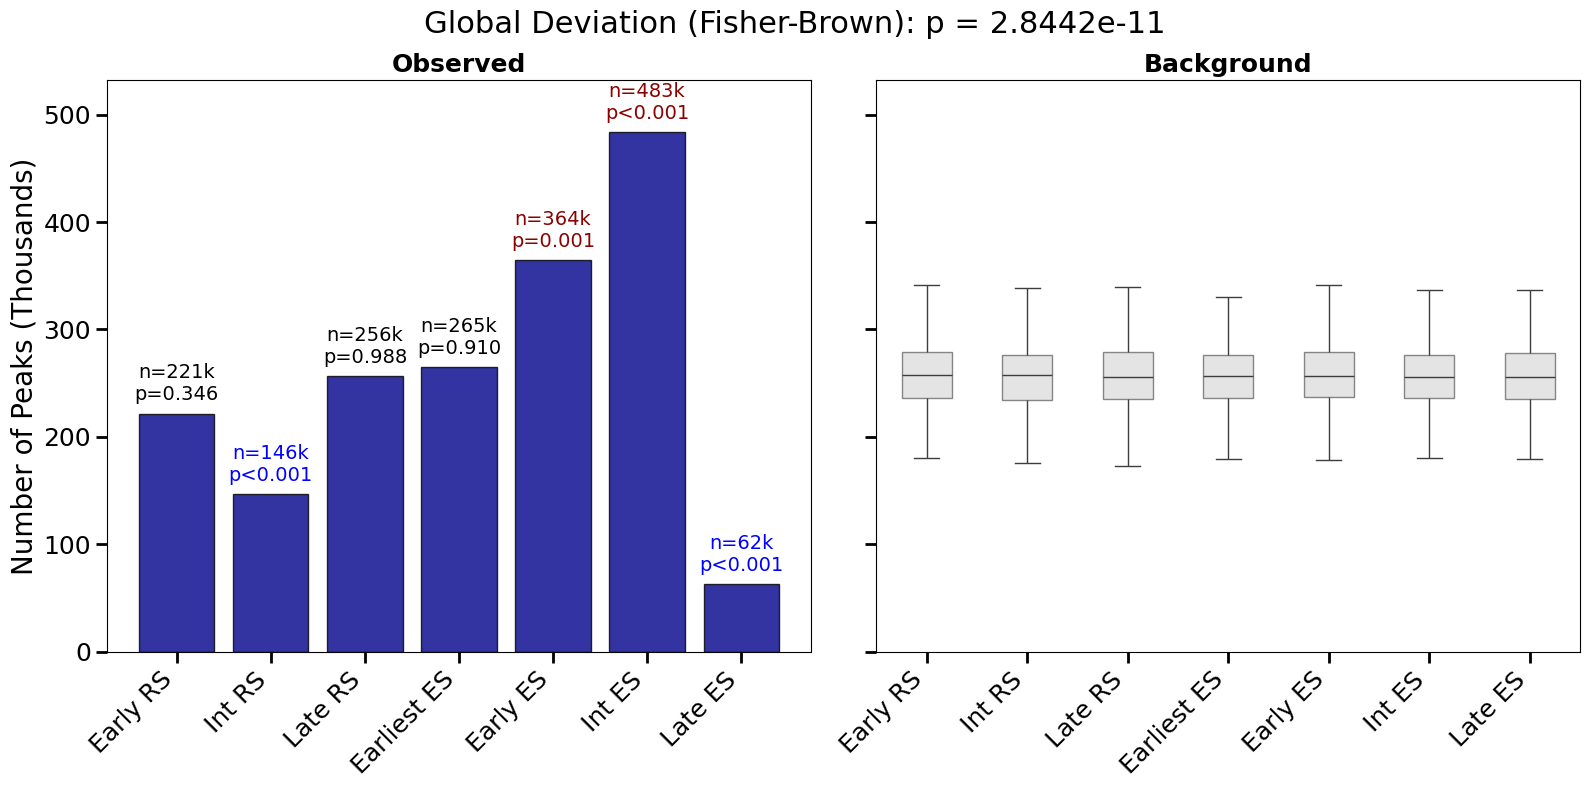

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# -----------------------------
# 1. LEFT PANEL: Observed Data (Barplot)
# -----------------------------
observed_vals = [observed_data[s] for s in stage_order]

# Plot the bars
bars = ax1.bar(stage_order, observed_vals, color='darkblue', edgecolor='black', alpha=0.8)

# --- Annotations ---
# Calculate offset for text (2% of the total range)
y_range = max(observed_vals) - min(observed_vals)
if y_range == 0: y_range = 100
y_offset = y_range * 0.02


for i, stage in enumerate(stage_order):
    row = summary_df[summary_df['Stage'] == stage].iloc[0]
    
    obs = row['Observed']
    fdr_p = row['FDR_Adj_P']
    z_score = row['Z_Score']
    
    # Color Logic for Text
    if fdr_p < 0.05:
        if z_score > 0:
            label_color = 'darkred' # Significant Enrichment
        else:
            label_color = 'blue'    # Significant Depletion
    else:
        label_color = 'black'       # Not Significant
    
    # Text Formatting
    if fdr_p < 0.001:
        p_text = "p<0.001"
    else:
        p_text = f"p={fdr_p:.3f}"
    
    # Add Text on top of bar
    ax1.text(x=i, y=obs + y_offset, s=f"n={int(obs/1000):,}k\n{p_text}", 
             ha='center', va='bottom', fontsize=14, color=label_color)

# Styling Left Panel
ax1.set_title("Observed", fontsize=18, weight='bold')
ax1.set_ylabel("Number of Peaks (Thousands)", fontsize=20)


ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}'))
#ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
ax1.set_xticklabels(stage_order, rotation=45, ha='right', fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.5)


# -----------------------------
# 2. RIGHT PANEL: Null Distribution (Boxplot)
# -----------------------------
sns.boxplot(data=null_df, order=stage_order, ax=ax2, color='lightgrey', 
            showfliers=False, width=0.5, boxprops=dict(alpha=0.6))

# Styling Right Panel
ax2.set_title("Background", fontsize=18, weight='bold')
ax2.set_xlabel("") # X-label is redundant with tick labels
ax2.set_xticklabels(stage_order, rotation=45, ha='right', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.5)


# -----------------------------
# 3. GLOBAL POLISH
# -----------------------------
# Determine the max Y value across both datasets to set a nice limit
max_data_point = max(max(observed_vals), null_df.max().max())
ax1.set_ylim(0, max_data_point * 1.1) # Add 10% headroom for annotations
# ax2 automatically follows ax1 due to sharey=True
ax1.tick_params(axis='both', which='major', labelsize=18, width=2, length=8)
ax1.tick_params(axis='both', which='minor', width=2, length=4)
ax2.tick_params(axis='both', which='major', labelsize=18, width=2, length=8)
ax2.tick_params(axis='both', which='minor', width=2, length=4)
ax1.grid(False)
ax2.grid(False)
# Global Title
p_text_global = f"{global_p_value:.4e}"
plt.suptitle(f"Global Deviation (Fisher-Brown): p = {p_text_global}", fontsize=22)

plt.tight_layout()
plt.savefig("figure_plots/final_figs/4a_Macs2_peak_counts_vs_null.png", dpi=300)
plt.show()



## Fig 4b: Dinucleosome peaks

In [18]:
dinuc_peak_dir = "analysis_data/dinucleosome_peak_bed"
earliest_ES_dinuc_peak_bed = dinuc_peak_dir + "/dinucleosome_regions_earliest_ES.bed"
early_ES_dinuc_peak_bed = dinuc_peak_dir + "/dinucleosome_regions_early_ES.bed"
early_RS_dinuc_peak_bed = dinuc_peak_dir + "/dinucleosome_regions_early_RS.bed"
int_ES_dinuc_peak_bed = dinuc_peak_dir + "/dinucleosome_regions_int_ES.bed"
int_RS_dinuc_peak_bed = dinuc_peak_dir + "/dinucleosome_regions_int_RS.bed"
late_ES_dinuc_peak_bed = dinuc_peak_dir + "/dinucleosome_regions_late_ES.bed"
late_RS_dinuc_peak_bed = dinuc_peak_dir + "/dinucleosome_regions_late_RS.bed"

In [ ]:
# --- 1. CONFIGURATION ---
rng = np.random.default_rng(seed=42)
num_permutations = 1000 
chrom_list = [f'chr{i}' for i in range(1, 20)] + ['chrX', 'chrY']

files_map = {
    'Early RS': early_RS_dinuc_peak_bed,
    'Int RS': int_RS_dinuc_peak_bed,
    'Late RS': late_RS_dinuc_peak_bed,
    'Earliest ES': earliest_ES_dinuc_peak_bed,
    'Early ES': early_ES_dinuc_peak_bed,
    'Int ES': int_ES_dinuc_peak_bed,
    'Late ES': late_ES_dinuc_peak_bed
}

stage_order = list(files_map.keys())
all_peak_files = list(files_map.values())

# --- 2. FAST PRE-COMPUTATION (COUNTS) ---
print("Pre-loading peak counts...")
counts_lookup = {}
for f in all_peak_files:
    if os.path.exists(f):
        try:
            df = pd.read_csv(f, sep="\t", header=None, usecols=[0], names=['chrom'])
            counts = df['chrom'].value_counts().reindex(chrom_list, fill_value=0)
            counts_lookup[f] = counts.to_dict()
        except Exception:
            counts_lookup[f] = {c: 0 for c in chrom_list}
    else:
        counts_lookup[f] = {c: 0 for c in chrom_list}

# --- 3. CALCULATE JACCARD MATRIX (THE NEW PART) ---
print("Calculating Jaccard Correlation Matrix...")
n_stages = len(stage_order)
jaccard_matrix = np.eye(n_stages) # Start with diagonal of 1s

# Pre-load BedTools objects to save time
beds = {}
for stage in stage_order:
    f_path = files_map[stage]
    if os.path.exists(f_path):
            # Sort is required for efficient Jaccard
        beds[stage] = BedTool(f_path).sort()
    else:
        beds[stage] = None

    # Calculate pairwise Jaccard
for i in range(n_stages):
    for j in range(i + 1, n_stages):
        stage_a = stage_order[i]
        stage_b = stage_order[j]
        res = beds[stage_a].jaccard(beds[stage_b])
        j_index = res['jaccard']
        jaccard_matrix[i, j] = j_index
        jaccard_matrix[j, i] = j_index

# Visualize the correlation matrix 
print("Pairwise Jaccard Indices (First 3x3):")
print(jaccard_matrix[:3, :3])

# --- 4. CALCULATE OBSERVED & NULLS ---
observed_data = {}
for stage in stage_order:
    f_path = files_map[stage]
    observed_data[stage] = sum(counts_lookup[f_path][c] for c in chrom_list)

null_data = {stage: [] for stage in stage_order}
for perm in range(num_permutations):
    for stage in stage_order:
        total = sum(counts_lookup[rng.choice(all_peak_files)][chrom] for chrom in chrom_list)
        null_data[stage].append(total)
null_df = pd.DataFrame(null_data)

# --- 5. INDIVIDUAL Z-SCORES ---
stats_results = []
raw_p_values = []
observed_z_list = []

for stage in stage_order:
    obs = observed_data[stage]
    null_mean = np.mean(null_data[stage])
    null_std = np.std(null_data[stage])
    
    z_score = (obs - null_mean) / null_std if null_std != 0 else 0
    observed_z_list.append(z_score)
    
    p_val = max(norm.sf(abs(z_score)) * 2, 1e-300)
    raw_p_values.append(p_val)
    
    stats_results.append({
        'Stage': stage, 'Observed': obs, 'Z_Score': z_score, 'P_Value': p_val
    })

_, adj_p_values, _, _ = multipletests(raw_p_values, method='fdr_bh')
for i, res in enumerate(stats_results):
    res['FDR_Adj_P'] = adj_p_values[i]

summary_df = pd.DataFrame(stats_results)

# --- 4. BROWN'S METHOD (The "Correlation-Corrected Fisher's") ---
# This tests: "Is the distribution significantly different from random?"
# It is robust to correlation and direction-independent.

# A. Calculate Fisher's Statistic (X)
# X = -2 * sum(ln(p))
fisher_stat = -2 * np.sum(np.log(raw_p_values))

# B. Calculate Expected Mean and Variance of X
k = len(raw_p_values)
expected_mean = 2 * k

# Variance depends on the covariance of the p-values
# Brown's approximation for covariance of (-2lnp_i, -2lnp_j) is based on correlation rho
var_sum = 0
for i in range(k):
    for j in range(i + 1, k):
        rho = jaccard_matrix[i, j]
        # Polynomial approximation for covariance (Brown 1975 / Kost & McDermott 2002)
        cov = 3.263 * rho + 0.710 * rho**2 + 0.027 * rho**3
        var_sum += cov

expected_var = 4 * k + 2 * var_sum

# Calculate Degrees of Freedom (f) and Scaling Factor (c) for the Chi-Square approximation
# We model X ~ c * ChiSq(f)
c = expected_var / (2 * expected_mean)
f = (2 * expected_mean**2) / expected_var

# Calculate Global P-Value
global_p_value = chi2.sf(fisher_stat / c, df=f)

print("\n=== DISTRIBUTION ANALYSIS (Brown's Method) ===")
print(summary_df)
print("-" * 30)
print(f"Fisher's Statistic:     {fisher_stat:.2f}")
print(f"Effective Deg. Freedom: {f:.2f} (vs {2*k} if independent)")
print(f"Global P-value:         {global_p_value:.4e}")



Pre-loading peak counts...
Calculating Jaccard Correlation Matrix...
Pairwise Jaccard Indices (First 3x3):
[[1.       0.596732 0.393294]
 [0.596732 1.       0.421487]
 [0.393294 0.421487 1.      ]]

=== DISTRIBUTION ANALYSIS (Brown's Method) ===
         Stage  Observed   Z_Score       P_Value     FDR_Adj_P
0     Early RS     21705  2.773690  5.542440e-03  7.759416e-03
1       Int RS     19695  1.984999  4.714457e-02  5.500200e-02
2      Late RS     36755  8.319511  8.832732e-17  6.182913e-16
3  Earliest ES     12905 -0.549821  5.824422e-01  5.824422e-01
4     Early ES      1656 -4.436061  9.162002e-06  2.137800e-05
5       Int ES      1499 -4.631242  3.634793e-06  1.272177e-05
6      Late ES      6219 -2.863880  4.184872e-03  7.323525e-03
------------------------------
Fisher's Statistic:     150.72
Effective Deg. Freedom: 7.71 (vs 14 if independent)
Global P-value:         8.4637e-15


/tmp/ipykernel_140233/1598973989.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(stage_order, rotation=45, ha='right', fontsize=12)
/tmp/ipykernel_140233/1598973989.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(stage_order, rotation=45, ha='right', fontsize=12)


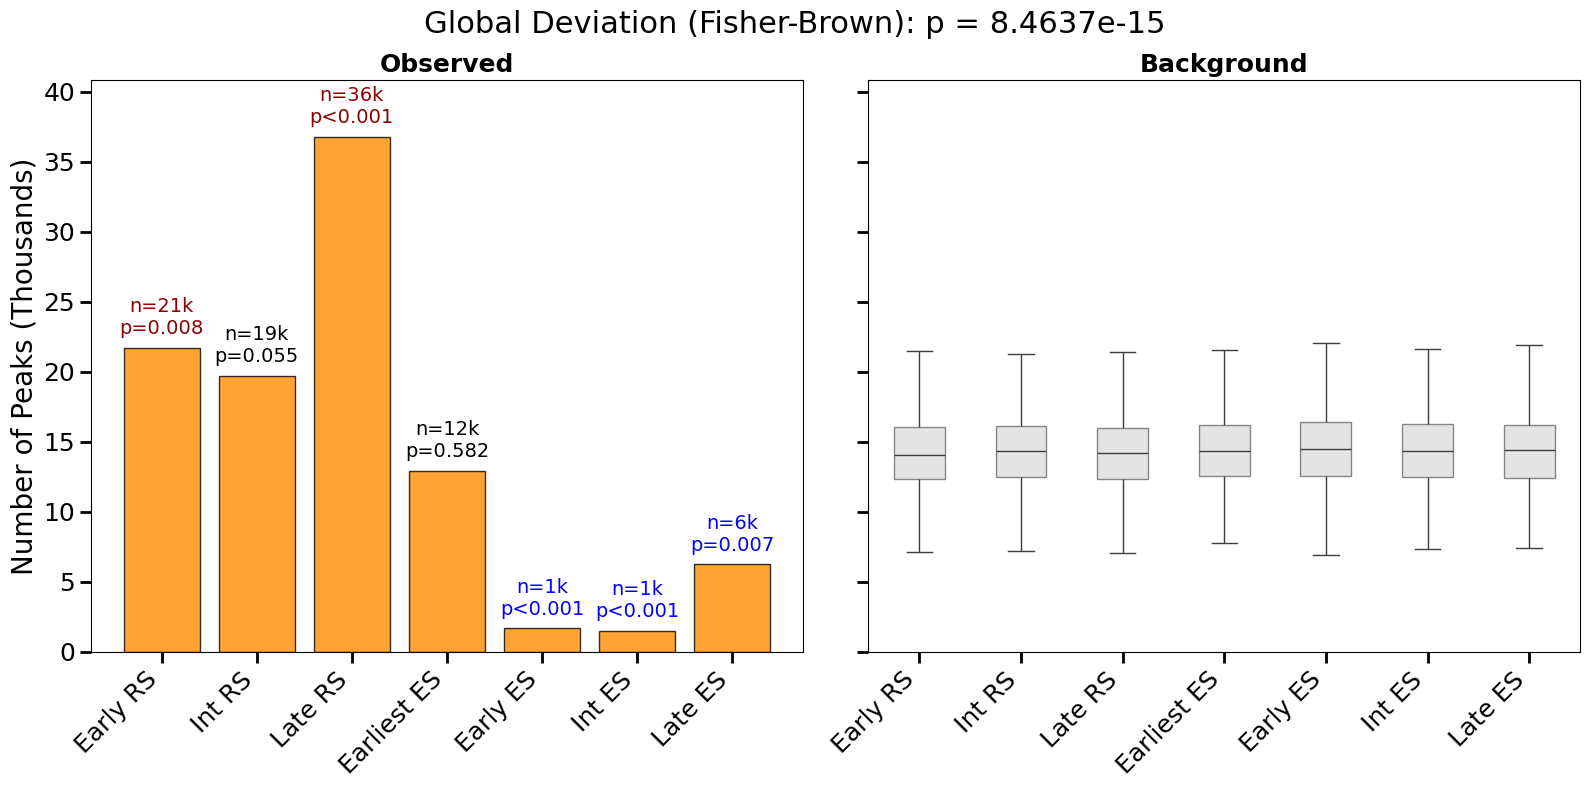

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# -----------------------------
# 1. LEFT PANEL: Observed Data (Barplot)
# -----------------------------
observed_vals = [observed_data[s] for s in stage_order]

# Plot the bars
bars = ax1.bar(stage_order, observed_vals, color='darkorange', edgecolor='black', alpha=0.8)

# --- Annotations ---
# Calculate offset for text (2% of the total range)
y_range = max(observed_vals) - min(observed_vals)
if y_range == 0: y_range = 100
y_offset = y_range * 0.02

for i, stage in enumerate(stage_order):
    row = summary_df[summary_df['Stage'] == stage].iloc[0]
    
    obs = row['Observed']
    fdr_p = row['FDR_Adj_P']
    z_score = row['Z_Score']
    
    # Color Logic for Text
    if fdr_p < 0.05:
        if z_score > 0:
            label_color = 'darkred' # Significant Enrichment
        else:
            label_color = 'blue'    # Significant Depletion
    else:
        label_color = 'black'       # Not Significant
    
    # Text Formatting
    if fdr_p < 0.001:
        p_text = "p<0.001"
    else:
        p_text = f"p={fdr_p:.3f}"
    
    # Add Text on top of bar
    ax1.text(x=i, y=obs + y_offset, s=f"n={int(obs/1000):,}k\n{p_text}", 
             ha='center', va='bottom', fontsize=14, color=label_color)

# Styling Left Panel
ax1.set_title("Observed", fontsize=18, weight='bold')
ax1.set_ylabel("Number of Peaks (Thousands)", fontsize=20)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}'))
ax1.set_xticklabels(stage_order, rotation=45, ha='right', fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.5)


# -----------------------------
# 2. RIGHT PANEL: Null Distribution (Boxplot)
# -----------------------------
sns.boxplot(data=null_df, order=stage_order, ax=ax2, color='lightgrey', 
            showfliers=False, width=0.5, boxprops=dict(alpha=0.6))

# Styling Right Panel
ax2.set_title("Background", fontsize=18, weight='bold')
ax2.set_xlabel("") # X-label is redundant with tick labels
ax2.set_xticklabels(stage_order, rotation=45, ha='right', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.5)


# -----------------------------
# 3. GLOBAL POLISH
# -----------------------------
# Determine the max Y value across both datasets to set a nice limit
max_data_point = max(max(observed_vals), null_df.max().max())
ax1.set_ylim(0, max_data_point * 1.11) # Add 10% headroom for annotations
# ax2 automatically follows ax1 due to sharey=True
ax1.tick_params(axis='both', which='major', labelsize=18, width=2, length=8)
ax1.tick_params(axis='both', which='minor', width=2, length=4)
ax2.tick_params(axis='both', which='major', labelsize=18, width=2, length=8)
ax2.tick_params(axis='both', which='minor', width=2, length=4)
ax1.grid(False)
ax2.grid(False)
# Global Title
p_text_global = f"{global_p_value:.4e}"
plt.suptitle(f"Global Deviation (Fisher-Brown): p = {p_text_global}", fontsize=22)

plt.tight_layout()
plt.savefig("figure_plots/final_figs/4b_Dinuc_peak_counts_vs_null.png", dpi=300)
plt.show()